In [1]:
from utils.binaries import *
from utils.plotting import *
from datetime import date, datetime

from utils.auger.fd.XYScanner import Telescope

21:41:33 (   +3.4s) [INFO   ] -- import logging
21:41:33 (   +84ms) [INFO   ] -- import numpy as np
21:41:33 (    +6ms) [INFO   ] -- import uncertainties
21:41:33 (  +206ms) [INFO   ] -- import pandas as pd
21:41:33 (    +1ms) [WARNING] -- pandas support to be dropped at some point!
21:41:33 (    +1ms) [INFO   ] -- import binaries.tools as tools
21:41:33 (    +1ms) [INFO   ] -- set MONI_PATH = PosixPath('/home/filip/Data/monit_and_sd')
21:41:33 (    +1ms) [INFO   ] -- set HIST_PATH = PosixPath('/home/filip/Data/monit_and_sd')
21:41:33 (    +0ms) [INFO   ] -- set PLOT_PATH = PosixPath('/home/filip/Data/plots')
21:41:33 (    +0ms) [INFO   ] -- set DATA_PATH = PosixPath('/home/filip/Data')
21:41:33 (    +0ms) [INFO   ] -- set SCAN_PATH = PosixPath('/home/filip/Public/xy-calibration')
21:41:33 (    +1ms) [INFO   ] -- set OFLN_PATH = PosixPath('/home/filip/Public/offline/install')
21:41:34 (  +255ms) [INFO   ] -- import matplotlib.pyplot as plt
21:41:34 (  +349ms) [INFO   ] -- import seabor

In [2]:
# CalA = tools.pickle_load("CO1.pkl")
# CalA = CalA.loc[CalA['PixelId'] == 210, ['Date', 'CalibConstant']]
# tools.pickle_save("CO1_pixel210.pkl", CalA)

CO1 = Telescope("CO1")[0]
CalA = tools.pickle_load("CO1_pixel210.pkl")
CalA.loc[CalA['CalibConstant'] > 10, 'CalibConstant'] = np.nan

21:49:18 (   +3.4s) [DEBUG  ] -- font size set to 9.5
21:49:18 (    +2ms) [DEBUG  ] -- label size set to 13.0
21:49:18 (    +0ms) [DEBUG  ] -- figure size set to [6.6, 2.2]
21:49:18 (    +1ms) [DEBUG  ] -- markersize set to 2.0
21:49:18 (    +0ms) [DEBUG  ] -- usetex set to False


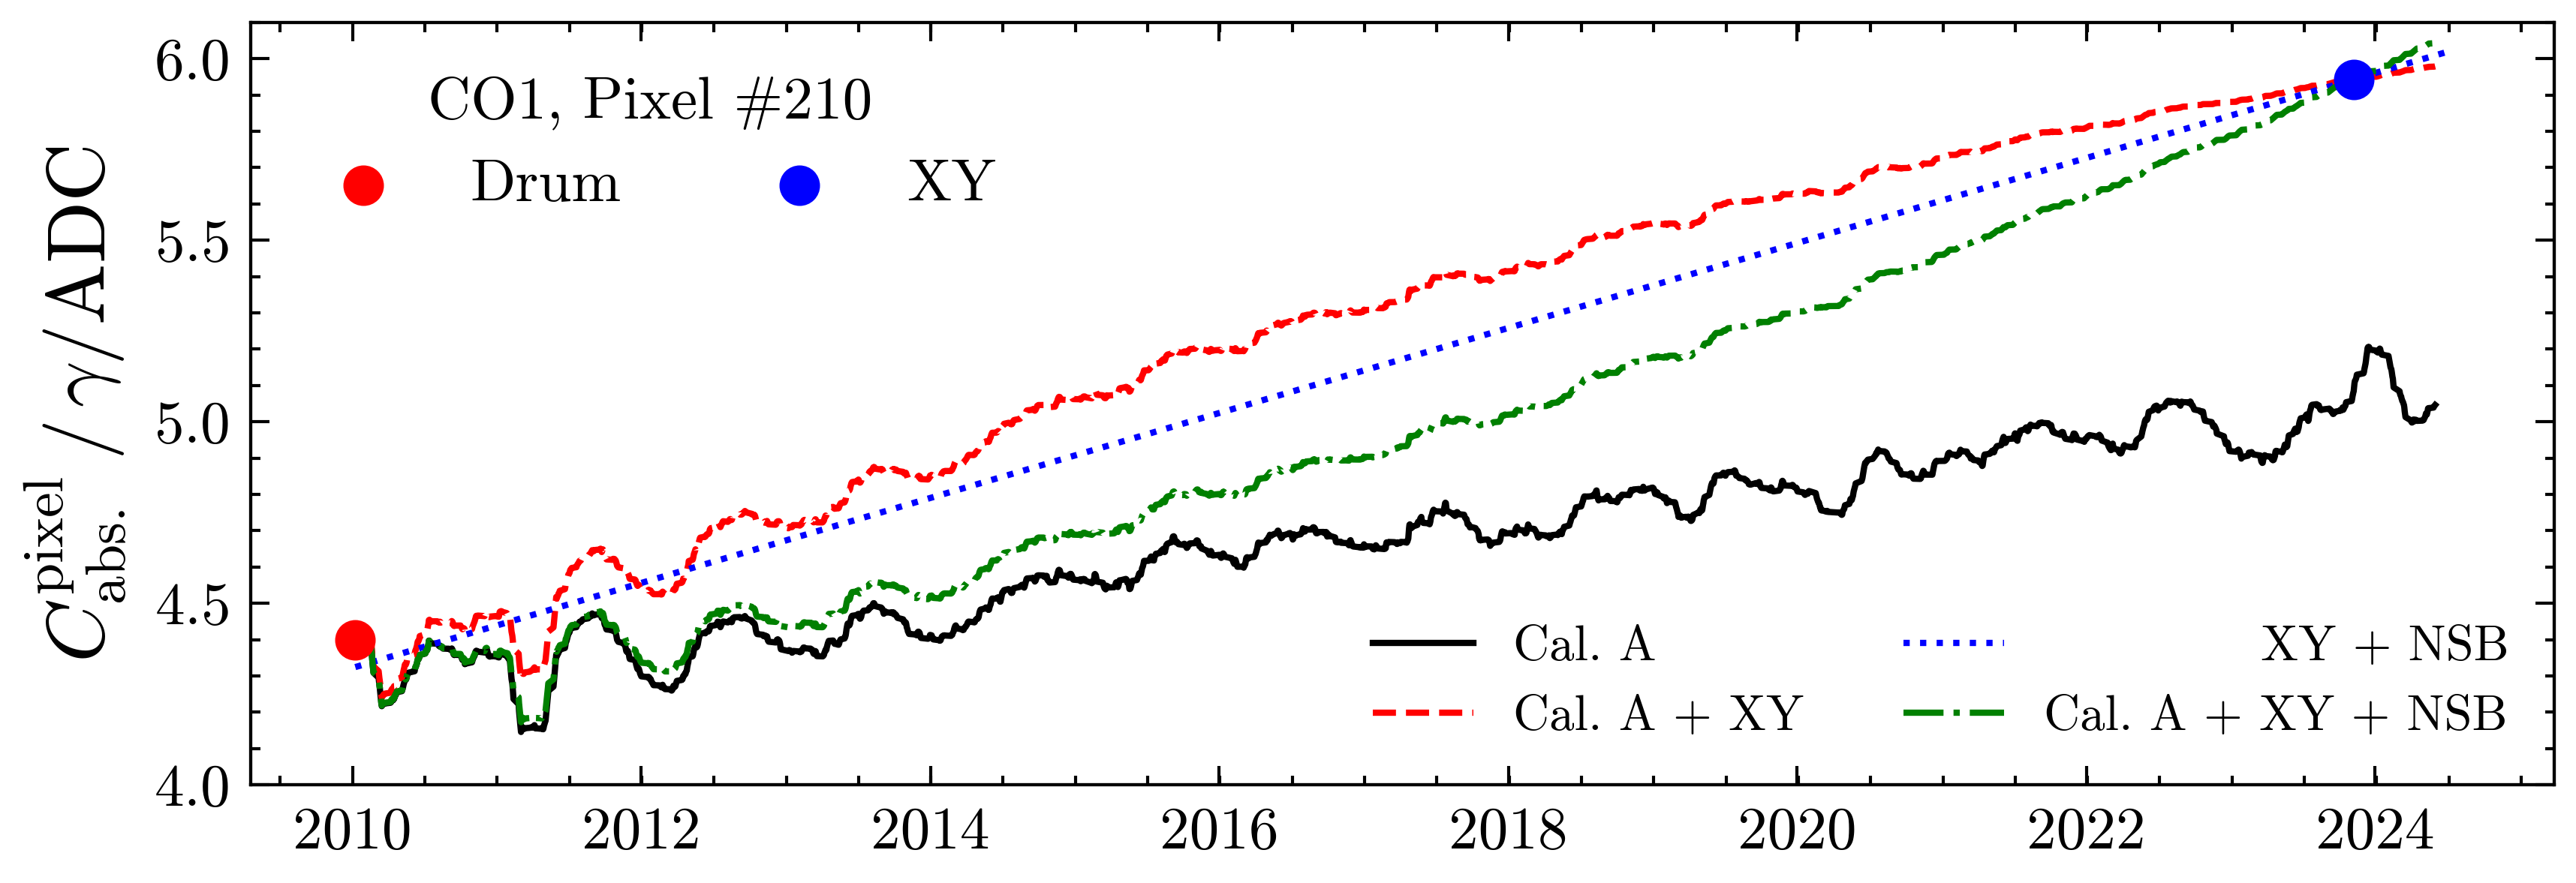

In [18]:
set_plt_style("slim")

XY_pixel = CO1.get_data("XY")[209]
XY_date = datetime.strptime(CO1.year_month_day, '%Y-%m-%d').date()
Drum_pixel = 4.4
Drum_date = CalA.iloc[0, 0]

def lin_int(x, y, start_date=Drum_date, stop_date=XY_date, stop_val=XY_pixel):
    x = np.array([(f - start_date).days for f in x])
    stop_date = (stop_date - start_date).days

    fraction_time = x / stop_date

    return y * (1-fraction_time) + stop_val * fraction_time

def nsb_drift(x, anchor_date=XY_date, anchor_val=XY_pixel, nsb_drift=0.019689854):

    x = np.array([(anchor_date-f).days / 365.25 for f in x])

    return anchor_val * (1-x*nsb_drift)

def nsb_drift_interpolation_cal_a(x, y, start_date=Drum_date, 
                                  stop_date=XY_date, stop_val=XY_pixel,
                                  nsb_drift=0.019689854):
    
    x1 = np.array([(stop_date-f).days / 365.25 for f in x])
    stop_val = stop_val * (1-x1*nsb_drift)

    x = np.array([(f - start_date).days for f in x])
    stop_date = (stop_date - start_date).days

    fraction_time = x / stop_date

    return y * (1-fraction_time) + stop_val * fraction_time

ax1 = plt.gca()

plt.scatter(Drum_date, Drum_pixel, s=30, c='r', zorder=1, label='Drum')
plt.scatter(XY_date, XY_pixel, s=30, c='b', label="XY")

ymin, ymax = 4, 6.1
xmin, xmax = plt.gca().get_xlim()
plt.gca().set_ylim(ymin, ymax)

plt.legend(ncol=2, title='CO1, Pixel #210')
plt.ylabel("$C^\mathrm{pixel}_\mathrm{abs.}\,/\,\gamma/\mathrm{ADC}$")

ax = plt.gca().twinx()
ax.set_ylim(ymin, ymax)
# ax.set_xlim(xmin, xmax)
ax.set_yticklabels([])
ax.set_zorder(ax1.get_zorder()-1)
ax1.patch.set_visible(False)

ax.plot(*tools.running_mean(CalA['Date'], CalA['CalibConstant'], 50), 
        marker='none', zorder=0, label='Cal. A')

ax.plot(*tools.running_mean(CalA['Date'], lin_int(CalA['Date'], CalA['CalibConstant']), 50), 
        marker='none', label='Cal. A + XY')

ax.plot(CalA['Date'], nsb_drift(CalA['Date']), marker='none', label='             XY + NSB')

ax.plot(*tools.running_mean(CalA['Date'], nsb_drift_interpolation_cal_a(CalA['Date'], CalA['CalibConstant']), 50), 
        marker='none', label='Cal. A + XY + NSB')

ax.legend(ncol=2, loc='lower right', fontsize=8)

In [ ]:
CalA['Date'][::9]